In [1]:
import torch

In [2]:
# Loading libraries

import datetime
import feedparser
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import yfinance as yf

from datetime import datetime, timedelta
from scipy.special import softmax
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification

api_key = "f89ee79ae79a47e7a7deaed69f638dbe"  # Replace with your actual News API key

In [3]:
# Create a Ticker object for Bitcoin and access the news data
btc = yf.Ticker("BTC-USD")
news_data = btc.news

# Print the desired information for each article
for article in news_data:
    content = article.get('content')
    if content:
        # Assuming title, publisher, link are now within 'content'
        print("Published Time:", content.get('pubDate'))
        print("Title:", content.get('title'))  
        print("Publisher:", content.get('provider').get('displayName'))  
        print("Link:", content.get('canonicalUrl').get('url'))
        print("Content Type:", content.get('contentType'))
        print("-" * 30)

Published Time: 2025-12-20T22:47:00Z
Title: 3 Reasons Why I'm Not Worried About Bitcoin Slipping Below $90,000
Publisher: Motley Fool
Link: https://www.fool.com/investing/2025/12/20/3-reasons-why-i-dont-worry-about-bitcoin-slipping/
Content Type: STORY
------------------------------
Published Time: 2025-12-20T21:30:13Z
Title: Tom Lee responds to controversy surrounding Fundstrat’s differing bitcoin outlooks
Publisher: CoinDesk
Link: https://www.coindesk.com/markets/2025/12/20/tom-lee-responds-as-x-debates-fundstrat-s-differing-bitcoin-outlooks
Content Type: STORY
------------------------------
Published Time: 2025-12-20T20:07:33Z
Title: Uniswap’s UNI Jumps 19% as governance vote to activate protocol fees opens
Publisher: CoinDesk
Link: https://www.coindesk.com/markets/2025/12/20/uniswap-s-uni-jumps-19-as-governance-vote-to-activate-protocol-fees-opens
Content Type: STORY
------------------------------
Published Time: 2025-12-20T19:52:24Z
Title: This Bitcoin Mining Stock Is Still 70% Be

In [4]:
# Define RSS feed URL and retrieve feed
query = "Bitcoin"
rss_url = f"https://news.google.com/rss/search?q={query}t&hl=en-US&gl=US&ceid=US:en"
feed = feedparser.parse(rss_url)

for entry in feed.entries:
    print("Published:", entry.published)
    print("Title:", entry.title)
    print("Link:", entry.link)
    print("-" * 30)

Published: Fri, 04 Apr 2025 07:00:00 GMT
Title: Warren Buffett Avoids Bitcoin, But Do You Know Berkshire Hathaway Owns Stake In A Company That Pitches BTC As 'Critical' Inflation Hedge - Yahoo Finance
Link: https://news.google.com/rss/articles/CBMihwFBVV95cUxNZkVTaHJYY2dfMHA0MThmbDdTcnBtaVB2VE51cjcxVjY1dnlZbm5KckMwbkhkWU9weFlyOUJFejB2VjFyekNOSmxqdUZIOVJiblpiaXRkU0NnV0JFQWREWjQ1dml4Qy1FQzRDXzlHMDJmd1BDcVVWaXdibEdvWElaLWx3N1BaMDA?oc=5
------------------------------
Published: Thu, 18 Dec 2025 16:21:50 GMT
Title: Taiwan Reveals It Holds 210 Bitcoin Seized in Criminal Cases, Valued at $18 Million - Bitcoin Magazine
Link: https://news.google.com/rss/articles/CBMid0FVX3lxTE1oSnZFWlh3T0lReTBTYWZ0blZmdUl0Ykl5NldWOGgxQXh2a3M3NFR2ZDIwT1QzVWVfOUVCcGhxZ3RDVmxRLXB3MnFLak9tTUhHUTYxYUNaVmJoX3RZRzRTLVR0eGJQRmRNTENVWUFKdVBpeFBoajVF?oc=5
------------------------------
Published: Wed, 03 Sep 2025 07:00:00 GMT
Title: Bilionaire Ray Dalio reiterates warnings of dollar decline, suggests Bitcoin as a hedge -

In [5]:
# Define News API variables
query = "Bitcoin"
url = f"https://newsapi.org/v2/everything?q={query}&apiKey={api_key}&language=en"
response = requests.get(url)

# Get news data
results = []
if response.status_code == 200:
    news_data = response.json()
    for article in news_data['articles']:
        results.append({
            'Date': article['publishedAt'][:10],  # Extract date
            'URL': article['url'],
            'Source': article['source']['name'],
            'Author': article['author'],
            'Title': article['title'],
            'Description': article['description'],
            'Content': article['content']
        })
else:
    print("Error fetching news:", response.status_code)

# Create DataFrame
df = pd.DataFrame(results)
df

,Date,URL,Source,Author,Title,Description,Content
0,2025-11-21,https://gizmodo.com/bitcoin-continues-steep-de...,Gizmodo.com,Matt Novak,"Bitcoin Continues Steep Decline, Down 34% Sinc...",The crypto bros are tired of winning.,Bitcoin’s price just keeps falling. And nobody...
1,2025-12-01,https://gizmodo.com/europol-shuts-down-bitcoin...,Gizmodo.com,Kyle Torpey,Europol Shuts Down Bitcoin Mixer That Processe...,Centralized mixing tools for obscuring crypto ...,European law enforcement struck a blow against...
2,2025-12-11,https://gizmodo.com/convicted-crypto-wallet-de...,Gizmodo.com,Kyle Torpey,Convicted Crypto Wallet Developer Warns Miners...,Many in the crypto world have been pleased wit...,"Keonne Rodriguez, who was recently sentenced t..."
3,2025-11-30,https://gizmodo.com/tether-usdt-sandp-downgrad...,Gizmodo.com,Kyle Torpey,Crypto’s Most Trusted Stablecoin Given Lowest ...,Trust the dusty old rating agency with the spo...,"Tether’s USDT, the dominant dollar-pegged stab..."
4,2025-11-23,https://gizmodo.com/homeland-security-is-repor...,Gizmodo.com,Kyle Torpey,Homeland Security Is Reportedly Probing Bitcoi...,And there's an additional Trump family connect...,"According to a new report from Bloomberg, fede..."
...,...,...,...,...,...,...,...
95,2025-11-24,https://www.thedailybeast.com/trump-family-for...,Daily Beast,Ewan Palmer,Trump Family Fortune Plummets in Stinging Cryp...,The Trump family fortune has plummeted by a bi...,Photo Illustration by Elizabeth Brockway/The D...
96,2025-12-17,https://www.theverge.com/news/845831/ai-chips-...,The Verge,Justine Calma,AI’s water and electricity use soars in 2025,AI created as much carbon pollution this year ...,<ul><li></li><li></li><li></li></ul>\r\nA new ...
97,2025-12-01,https://www.businessinsider.com/yen-carry-trad...,Business Insider,jsor@businessinsider.com (Jennifer Sor),Why Japan's central bank is stirring up fresh ...,Investors were fretting about interest rates i...,The Bank of Japan raised fears about a repeat ...
98,2025-11-21,https://gizmodo.com/bitcoin-developers-pardon-...,Gizmodo.com,Kyle Torpey,Bitcoin Developers’ Pardon Request Creates Awk...,It's demonstrably worth a try.,The two developers behind the privacy-focused ...


In [6]:
# Save News dataset
df.to_csv('news_data.csv', index=False)

In [7]:
# Specify the FinBERT model
MODEL = f"ProsusAI/finbert"
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForSequenceClassification.from_pretrained(MODEL)

# Text processing function
def preprocess(text):
    if text is None: # Handle None values by returning an empty string if text is None
        return ""
    new_text = []
    for t in text.split(" "):
        t = '' if t.startswith('#') and len(t) > 1 else t  # remove hashtags
        t = '' if t.startswith('@') and len(t) > 1 else t  # remove usernames
        t = '' if t.startswith('http') else t  # remove URLs
        new_text.append(t)
    return " ".join(new_text)

# Sentiment scoring function
def get_sentiment(text):
    text = preprocess(text)
    encoded_input = tokenizer(text, return_tensors='pt')
    output = model(**encoded_input)
    scores = output[0][0].detach().numpy()
    scores = softmax(scores)
    return {
        'positive': scores[0],
        'negative': scores[1],
        'neutral': scores[2]
    }

In [8]:
# Remove rows with "[Removed]" or None in Description
df = df[df['Description'] != '[Removed]']
df = df.dropna(subset=['Description'])

# Apply sentiment scoring to the 'description' column and create new columns
df.loc[:, 'Sent_positive'] = df['Description'].apply(lambda x: get_sentiment(x)['positive'])
df.loc[:, 'Sent_negative'] = df['Description'].apply(lambda x: get_sentiment(x)['negative'])
df.loc[:, 'Sent_neutral'] = df['Description'].apply(lambda x: get_sentiment(x)['neutral'])
df

,Date,URL,Source,Author,Title,Description,Content,Sent_positive,Sent_negative,Sent_neutral
0,2025-11-21,https://gizmodo.com/bitcoin-continues-steep-de...,Gizmodo.com,Matt Novak,"Bitcoin Continues Steep Decline, Down 34% Sinc...",The crypto bros are tired of winning.,Bitcoin’s price just keeps falling. And nobody...,0.015456,0.829943,0.154601
1,2025-12-01,https://gizmodo.com/europol-shuts-down-bitcoin...,Gizmodo.com,Kyle Torpey,Europol Shuts Down Bitcoin Mixer That Processe...,Centralized mixing tools for obscuring crypto ...,European law enforcement struck a blow against...,0.024691,0.300511,0.674798
2,2025-12-11,https://gizmodo.com/convicted-crypto-wallet-de...,Gizmodo.com,Kyle Torpey,Convicted Crypto Wallet Developer Warns Miners...,Many in the crypto world have been pleased wit...,"Keonne Rodriguez, who was recently sentenced t...",0.216982,0.323946,0.459072
3,2025-11-30,https://gizmodo.com/tether-usdt-sandp-downgrad...,Gizmodo.com,Kyle Torpey,Crypto’s Most Trusted Stablecoin Given Lowest ...,Trust the dusty old rating agency with the spo...,"Tether’s USDT, the dominant dollar-pegged stab...",0.039186,0.079098,0.881716
4,2025-11-23,https://gizmodo.com/homeland-security-is-repor...,Gizmodo.com,Kyle Torpey,Homeland Security Is Reportedly Probing Bitcoi...,And there's an additional Trump family connect...,"According to a new report from Bloomberg, fede...",0.078726,0.014407,0.906867
...,...,...,...,...,...,...,...,...,...,...
95,2025-11-24,https://www.thedailybeast.com/trump-family-for...,Daily Beast,Ewan Palmer,Trump Family Fortune Plummets in Stinging Cryp...,The Trump family fortune has plummeted by a bi...,Photo Illustration by Elizabeth Brockway/The D...,0.010297,0.933977,0.055726
96,2025-12-17,https://www.theverge.com/news/845831/ai-chips-...,The Verge,Justine Calma,AI’s water and electricity use soars in 2025,AI created as much carbon pollution this year ...,<ul><li></li><li></li><li></li></ul>\r\nA new ...,0.118918,0.027633,0.853449
97,2025-12-01,https://www.businessinsider.com/yen-carry-trad...,Business Insider,jsor@businessinsider.com (Jennifer Sor),Why Japan's central bank is stirring up fresh ...,Investors were fretting about interest rates i...,The Bank of Japan raised fears about a repeat ...,0.023041,0.932329,0.044630
98,2025-11-21,https://gizmodo.com/bitcoin-developers-pardon-...,Gizmodo.com,Kyle Torpey,Bitcoin Developers’ Pardon Request Creates Awk...,It's demonstrably worth a try.,The two developers behind the privacy-focused ...,0.268751,0.009992,0.721257


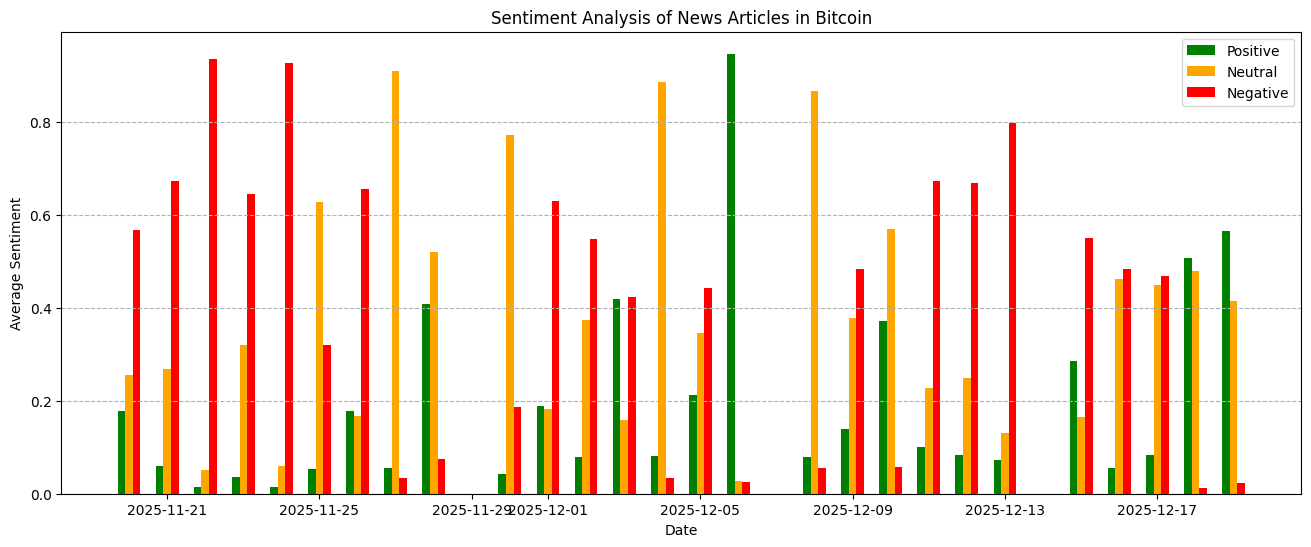

In [9]:
# Group by date and calculate average sentiment scores
df_grouped = df.groupby('Date').agg(['sum', 'count'])  # Get sum and count

# Create new columns for normalized sentiment scores
df_grouped['avg_positive'] = df_grouped['Sent_positive']['sum'] / df_grouped['Sent_positive']['count']  # Normalize positive
df_grouped['avg_negative'] = df_grouped['Sent_negative']['sum'] / df_grouped['Sent_negative']['count']  # Normalize negative
df_grouped['avg_neutral'] = df_grouped['Sent_neutral']['sum'] / df_grouped['Sent_neutral']['count']  # Normalize neutral

# Convert df_grouped.index to DatetimeIndex
df_grouped.index = pd.to_datetime(df_grouped.index)

# Plot the sentiment data
fig, ax = plt.subplots(figsize=(16, 6))
width = 0.2
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped['avg_positive'], width=width, label='Positive', color='green')
ax.bar(df_grouped.index, df_grouped['avg_neutral'], width=width, label='Neutral', color='orange')
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped['avg_negative'], width=width, label='Negative', color='red')

# Set plot attributes (labels, ticks, title, legend, gridlines)
ax.set_xlabel('Date')
ax.set_ylabel('Average Sentiment')
ax.set_title('Sentiment Analysis of News Articles in Bitcoin')
ax.legend()
ax.grid(True, axis='y', linestyle='--')
plt.show()

C:\Users\OLUTUNMIBI IFEOLUWA\AppData\Local\Temp\ipykernel_8556\980620214.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start=df_grouped.index.min(), end=df_grouped.index.max())
[*********************100%***********************]  1 of 1 completed


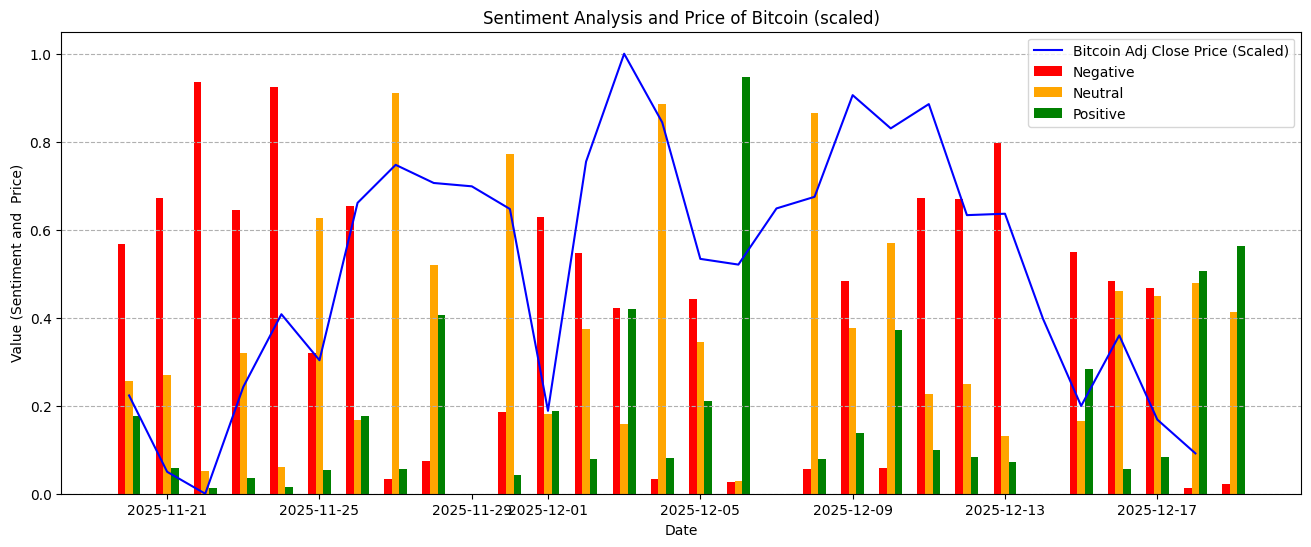

In [10]:
# Fetch Bitcoin data for the same date range
btc = yf.download("BTC-USD", start=df_grouped.index.min(), end=df_grouped.index.max())

# Scale the Microsoft price data
scaler = MinMaxScaler()
scaled_stock_price = scaler.fit_transform(btc[['Close']])

# Plot scaled price plot
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(btc.index, scaled_stock_price, color='blue', label='Bitcoin Adj Close Price (Scaled)')

# Plot the sentiment data
width = 0.2  # Adjust the width as needed
ax.bar(df_grouped.index - pd.DateOffset(days=width), df_grouped['avg_negative'], width=width, label='Negative', color='red')
ax.bar(df_grouped.index, df_grouped['avg_neutral'], width=width, label='Neutral', color='orange')
ax.bar(df_grouped.index + pd.DateOffset(days=width), df_grouped['avg_positive'], width=width, label='Positive', color='green')

# Set plot attributes (labels, ticks, title, legend, gridlines)
ax.set_xlabel('Date')
ax.set_title('Sentiment Analysis and Price of Bitcoin (scaled)')
ax.set_ylabel('Value (Sentiment and  Price)')
ax.legend()
ax.grid(True, axis='y', linestyle='--')
plt.show()

In [11]:
# Preprocessing 'Description' column in df
df.loc[:, 'Processed_Description'] = df['Description'].apply(lambda x: preprocess(x))

In [12]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=250, stop_words='english')
dtm = vectorizer.fit_transform(df['Processed_Description'])
dtm.shape

(94, 250)

In [13]:
# NMF
nmf_model = NMF(n_components=5, random_state=42) # 5 topics
W = nmf_model.fit_transform(dtm)
H = nmf_model.components_


In [14]:
# Retrieves the names of the features (words)
feature_names = vectorizer.get_feature_names_out()

# Extract top words
n_top_words = 10  # Top 10 words
for topic_idx, topic in enumerate(H):
    print(f"\nTopic {topic_idx + 1}:")
    print(" ".join([feature_names[i]
                    for i in topic.argsort()[:-n_top_words - 1:-1]]))


Topic 1:
bitcoin 000 btc october record 2025 billion million world usd

Topic 2:
crypto trump president btc executive bitcoin etf jpmorgan doubled controversy

Topic 3:
cycle monday hit mount questions prices high 92 market 000

Topic 4:
market trillion cap total crash cryptocurrency 24 hours fell nov

Topic 5:
just time 30 year little high month big money hitting


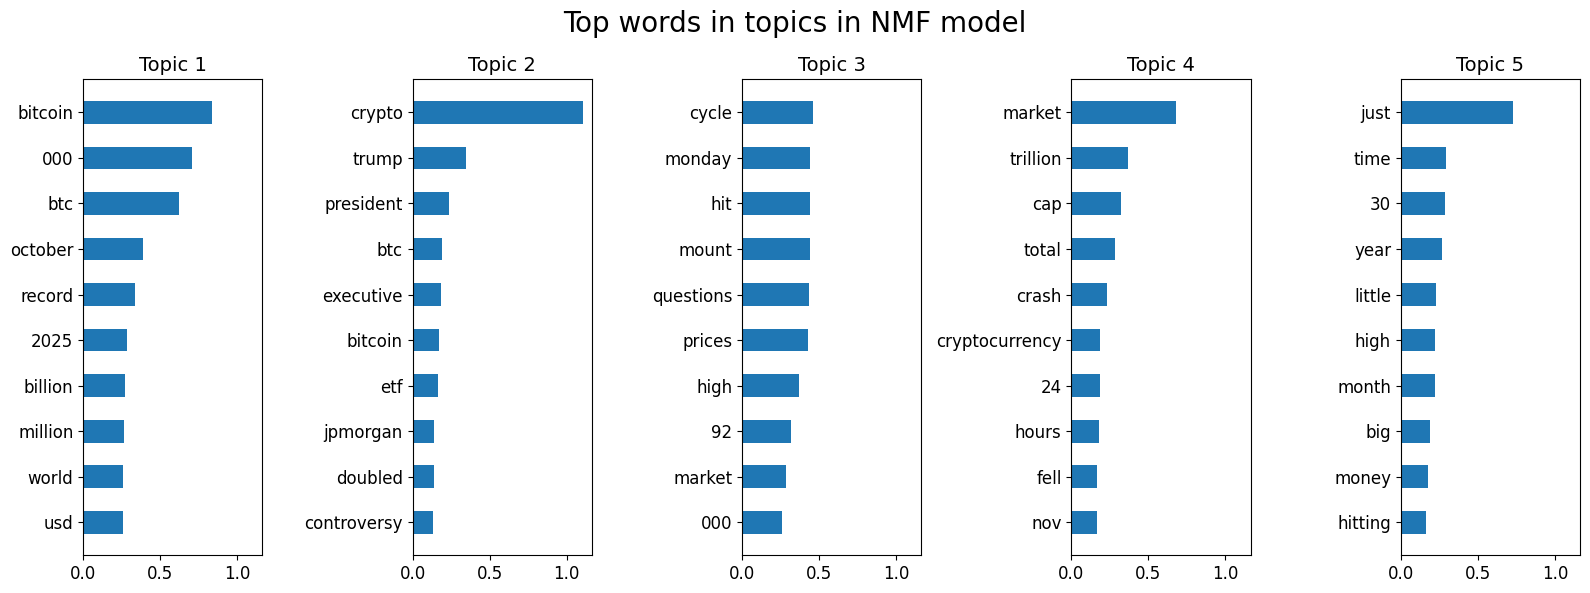

In [15]:
# Set figure size
fig, axes = plt.subplots(1, nmf_model.n_components, figsize=(16, 6), sharex=True)
axes = axes.flatten()  # Convert to 1D array for easier indexing

# Plot bar subplots for each topic
for topic_idx, topic in enumerate(H):
    top_features_ind = topic.argsort()[:-n_top_words - 1:-1]
    top_features = [feature_names[i] for i in top_features_ind]
    weights = topic[top_features_ind]

    ax = axes[topic_idx]
    ax.barh(top_features, weights, height=0.5, fill='blue')
    ax.set_title(f'Topic {topic_idx + 1}', fontdict={'fontsize': 14})
    ax.invert_yaxis()
    ax.tick_params(axis='both', which='major', labelsize=12)

# Set figure attributes (title)
fig.suptitle('Top words in topics in NMF model', fontsize=20, y=0.98)
fig.tight_layout(h_pad=2.0)
plt.show()


In [16]:
# Assigns the dominant topic for each document
df['Dominant_Topic'] = W.argmax(axis=1) + 1  # +1 to start topic numbering from 1

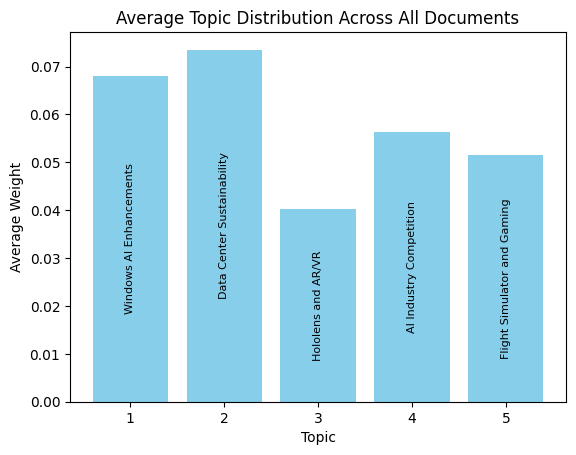

In [17]:
# Visualize average topic distribution across all documents
avg_topic_distribution = W.mean(axis=0)

# Define topic labels
topic_labels = ["Windows AI Enhancements", "Data Center Sustainability",
                "Hololens and AR/VR", "AI Industry Competition",
                "Flight Simulator and Gaming"]

# Create bar plot
bars = plt.bar(np.arange(nmf_model.n_components) + 1, avg_topic_distribution, color='skyblue')

# Add bar labels inside bars
for bar, label in zip(bars, topic_labels):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() / 2, label,
             ha='center', va='center', rotation=90, color='black', fontsize=8)

plt.xticks(np.arange(nmf_model.n_components) + 1)
plt.xlabel("Topic")
plt.ylabel("Average Weight")
plt.title("Average Topic Distribution Across All Documents")
plt.show()
